# Citalid Risk Engine — 01 · Data audit

A narrated audit of the four source files in `data/`, run before a single line of
modeling code. Its job is to *establish and justify* the constants the engine
depends on — the observation window, the cross-feed dedup key, the EDR→SIEM
severity mapping, the loss-distribution family and the peer group — so that
`risk_engine` can recompute them rather than hardcode them.

Each section states a finding, evidences it, and closes with a **Decision:** line.
Every decision below is implemented in `risk_engine`; this notebook is where it is
*argued*.

**Contents**

| § | Question |
|---|---|
| 1 | What are we defending? Asset inventory. |
| 2 | Over what period do we observe it? Coverage and the annualization factor. |
| 3 | Do the two feeds see the same events? Cross-feed duplication. |
| 4 | Do they speak the same severity language? Deriving the EDR cut points. |
| 5 | What kind of activity is it? Event mix. |
| 6 | Is the external incident base clean? Encoding and sentinels. |
| 7 | What shape are the losses? Tail and distribution family. |
| 8 | Who are the peers? Sample size vs relevance. |

In [1]:
"""Setup: imports, paths and a consistent chart style for the whole notebook."""

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

%matplotlib inline

# Resolve data/ by walking up from the notebook, so it runs from anywhere
# (jupyter, nbconvert, CI) without a hardcoded absolute path.
def find_data_dir(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "cyber_incidents.csv").exists():
            return candidate / "data"
    raise FileNotFoundError(f"data/ not found above {start}")


DATA = find_data_dir()

# --- presentation ---------------------------------------------------------
NAVY, ACCENT, WARN = "#0A1120", "#38BDF8", "#F59E0B"
SEQ = ["#0A1120", "#1E3A5F", "#2C6E9B", "#38BDF8"]  # Low -> Critical
mpl.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.labelcolor": "#334155",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.size": 10,
    "legend.frameon": False,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

SEV_ORDER = ["Low", "Medium", "High", "Critical"]


def eur(x):
    """Format a euro amount compactly for chart labels."""
    for unit, div in (("M", 1e6), ("k", 1e3)):
        if abs(x) >= div:
            return f"EUR {x / div:,.1f}{unit}"
    return f"EUR {x:,.0f}"


def bar_labels(ax, fmt="{:,.0f}", fontsize=8):
    """Annotate every bar in an axes with its value."""
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda v: fmt.format(v), padding=3,
                     fontsize=fontsize, color="#475569")


print("data directory:", DATA)
print("files:", sorted(p.name for p in DATA.glob("*.csv")))

data directory: D:\projects\crq\data
files: ['asset_reference.csv', 'cyber_incidents.csv', 'feed_edr.csv', 'feed_siem.csv']


In [2]:
"""Load the four sources with their native schemas.

No cleaning yet - section 6 is where the incident base gets repaired, and the raw
state belongs on the record.
"""

assets = pd.read_csv(DATA / "asset_reference.csv")
siem = pd.read_csv(DATA / "feed_siem.csv", parse_dates=["detected_at"])
edr = pd.read_csv(DATA / "feed_edr.csv", parse_dates=["timestamp"])
incidents = pd.read_csv(DATA / "cyber_incidents.csv", parse_dates=["date"])

sources = [("asset_reference", assets), ("feed_siem", siem),
           ("feed_edr", edr), ("cyber_incidents", incidents)]
for name, frame in sources:
    print(f"{name:18s} {frame.shape[0]:>6,} rows x {frame.shape[1]:>2} cols   "
          f"{', '.join(frame.columns)}")

print("\nMissing values (columns with at least one gap):")
for name, frame in sources:
    na = frame.isna().sum()
    na = na[na > 0]
    print(f"  {name:18s} {na.to_dict() if len(na) else 'none'}")

print("\nExactly duplicated rows:")
for name, frame in sources:
    print(f"  {name:18s} {frame.duplicated().sum():>5,}")

asset_reference        20 rows x  4 cols   asset_id, asset_type, business_criticality, environment
feed_siem          26,490 rows x  6 cols   event_id, asset_id, mitre_technique, severity, detected_at, source
feed_edr           19,350 rows x  5 cols   id, host, ttp, risk, timestamp
cyber_incidents     1,600 rows x 12 cols   incident_id, company_id, date, sector, company_size, employees, attack_type, severity, security_maturity_score, records_exposed, downtime_hours, financial_loss_eur

Missing values (columns with at least one gap):
  asset_reference    none
  feed_siem          {'asset_id': 105, 'severity': 317, 'source': 1059}
  feed_edr           {'ttp': 387}
  cyber_incidents    {'records_exposed': 48, 'downtime_hours': 80}

Exactly duplicated rows:
  asset_reference        0
  feed_siem            681
  feed_edr             543
  cyber_incidents        0


Three things to carry forward before any analysis. The telemetry is **not clean**:
the SIEM is missing `asset_id` on 105 rows, `severity` on 317 and `source` on 1,059,
and the EDR is missing `ttp` on 387. Both feeds also contain **exactly duplicated
rows** — 681 in the SIEM, 543 in the EDR — so the identifier columns are not unique
keys either.

None of this is fatal, but all of it has to be handled explicitly rather than
absorbed silently: a missing `asset_id` cannot participate in a dedup key, and a
missing `severity` cannot vote on a severity threshold. Each section below states
what it excludes and how many rows that costs.

---

## 1 · Asset inventory — what is being defended

Twenty assets, four types, three environments, business criticality on a 1–5 scale.
This is the only file carrying *business context*: the telemetry feeds know an
`asset_id` but nothing about what it is worth.

20 assets, 20 unique ids (duplicates: 0)


environment,dev,prod,staging,total
asset_type,,,,
database,1,2,0,3
server,1,4,2,7
web_app,1,1,0,2
workstation,1,5,2,8
total,4,12,4,20


criticality 1-5: {1: 2, 2: 5, 3: 7, 4: 4, 5: 2}
prod share: 60% | criticality >= 4: 30%


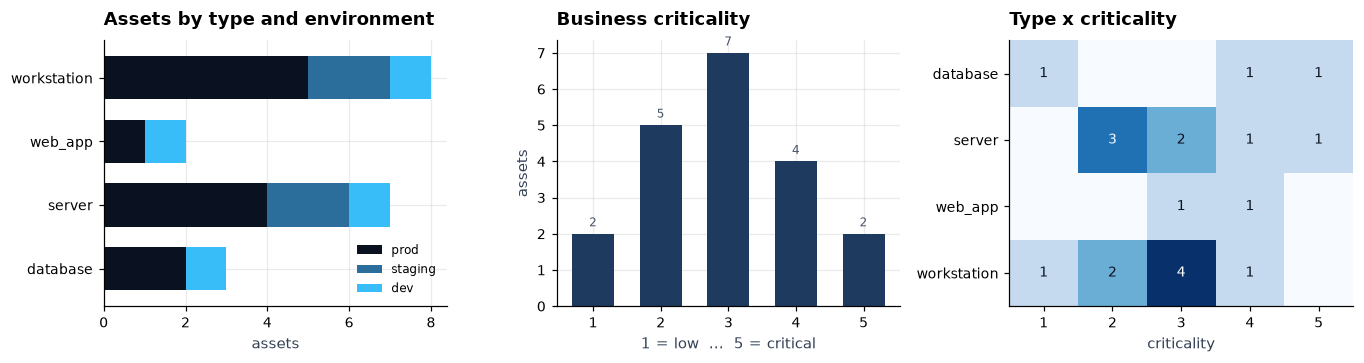

In [3]:
print(f"{len(assets)} assets, {assets.asset_id.nunique()} unique ids "
      f"(duplicates: {len(assets) - assets.asset_id.nunique()})")

display(pd.crosstab(assets.asset_type, assets.environment,
                    margins=True, margins_name="total"))

crit_counts = assets.business_criticality.value_counts().sort_index()
print("criticality 1-5:", crit_counts.to_dict())
print("prod share:", f"{assets.environment.eq('prod').mean():.0%}",
      "| criticality >= 4:", f"{assets.business_criticality.ge(4).mean():.0%}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

ct = pd.crosstab(assets.asset_type, assets.environment)[["prod", "staging", "dev"]]
ct.plot(kind="barh", stacked=True, ax=axes[0], color=[NAVY, "#2C6E9B", ACCENT], width=0.68)
axes[0].set_title("Assets by type and environment")
axes[0].set_xlabel("assets")
axes[0].set_ylabel("")
axes[0].legend(title=None, fontsize=8, loc="lower right")

axes[1].bar(crit_counts.index, crit_counts.to_numpy(), color=SEQ[1], width=0.62)
axes[1].set_title("Business criticality")
axes[1].set_xlabel("1 = low  ...  5 = critical")
axes[1].set_ylabel("assets")
axes[1].set_xticks([1, 2, 3, 4, 5])
bar_labels(axes[1])

pivot = pd.crosstab(assets.asset_type, assets.business_criticality)
values = pivot.to_numpy()
axes[2].imshow(values, cmap="Blues", aspect="auto")
axes[2].set_xticks(range(pivot.shape[1]), pivot.columns)
axes[2].set_yticks(range(pivot.shape[0]), pivot.index)
axes[2].set_title("Type x criticality")
axes[2].set_xlabel("criticality")
axes[2].grid(False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        if values[i, j]:
            axes[2].text(j, i, values[i, j], ha="center", va="center", fontsize=9,
                         color="white" if values[i, j] > values.max() * 0.6 else NAVY)

plt.tight_layout()
plt.show()

The inventory is small and unbalanced: 12 of 20 assets are production, and the six
assets rated criticality 4–5 are concentrated in `server` and `database`. Nothing
here is a modeling input on its own — but it is the only place criticality and
environment exist, so any weighting by business impact must join back to this file
rather than infer importance from the feeds.

**Decision:** the asset reference is the single source of business context. `risk_engine.ingestion` joins telemetry to it on `asset_id` and treats `business_criticality` and `environment` as asset attributes, never as anything derived from event volume or severity.

---

## 2 · Telemetry coverage — the observation window and the annualization factor

Every frequency the engine produces is an *annual* rate derived from a window
shorter than a year. The scaling factor is therefore a first-class model input, and
it has to be computed from the data rather than assumed.

,first_event,last_event,events,calendar_days_seen
siem,2025-11-01 00:02:32,2026-05-31 23:59:06,26490,212
edr,2025-11-01 00:02:32,2026-05-31 23:59:42,19350,212


observed window : 2025-11-01 00:02:32  ->  2026-05-31 23:59:42
elapsed span    : 211.9980 days (last - first timestamp)
observed days   : 212 distinct calendar days
annualization   : 365 / 212 = 1.721698
cross-check     : 365 / 211.9980 = 1.721714  (relative gap 9.3e-06)


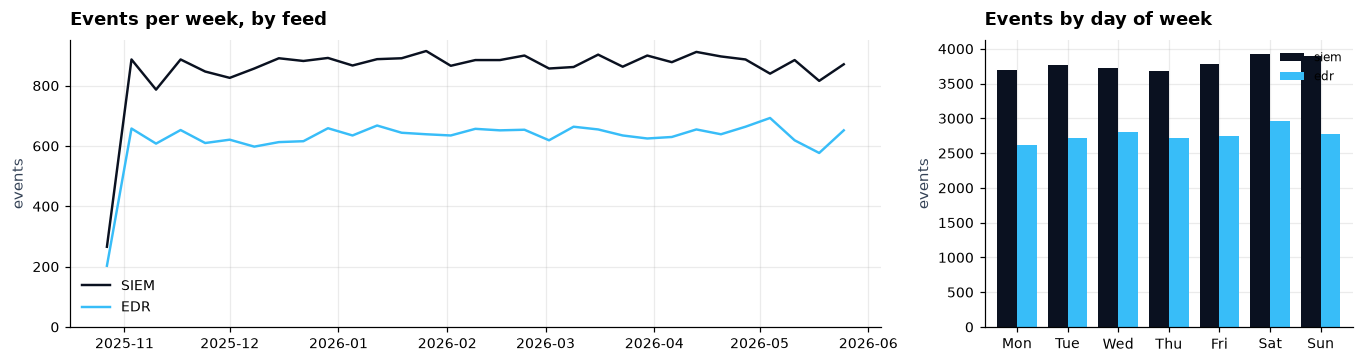

In [4]:
display(pd.DataFrame({
    "first_event": [siem.detected_at.min(), edr.timestamp.min()],
    "last_event": [siem.detected_at.max(), edr.timestamp.max()],
    "events": [len(siem), len(edr)],
    "calendar_days_seen": [siem.detected_at.dt.date.nunique(),
                           edr.timestamp.dt.date.nunique()],
}, index=["siem", "edr"]))

start = min(siem.detected_at.min(), edr.timestamp.min())
end = max(siem.detected_at.max(), edr.timestamp.max())
span_days = (end - start).total_seconds() / 86_400
observed_days = pd.date_range(start.normalize(), end.normalize(), freq="D").size
annualization = 365.0 / observed_days

print(f"observed window : {start}  ->  {end}")
print(f"elapsed span    : {span_days:.4f} days (last - first timestamp)")
print(f"observed days   : {observed_days} distinct calendar days")
print(f"annualization   : 365 / {observed_days} = {annualization:.6f}")
print(f"cross-check     : 365 / {span_days:.4f} = {365 / span_days:.6f}  "
      f"(relative gap {abs(365 / span_days - annualization) / annualization:.1e})")

weekly = pd.concat([
    siem.detected_at.dt.to_period("W").value_counts().rename("siem"),
    edr.timestamp.dt.to_period("W").value_counts().rename("edr"),
], axis=1).sort_index()
weekly.index = weekly.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4), width_ratios=[2.2, 1])
axes[0].plot(weekly.index, weekly.siem, color=NAVY, lw=1.6, label="SIEM")
axes[0].plot(weekly.index, weekly.edr, color=ACCENT, lw=1.6, label="EDR")
axes[0].set_title("Events per week, by feed")
axes[0].set_ylabel("events")
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=9)

by_dow = pd.concat([
    siem.detected_at.dt.dayofweek.value_counts().rename("siem"),
    edr.timestamp.dt.dayofweek.value_counts().rename("edr"),
], axis=1).sort_index()
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow.plot(kind="bar", ax=axes[1], color=[NAVY, ACCENT], width=0.78, rot=0)
axes[1].set_title("Events by day of week")
axes[1].set_ylabel("events")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Both feeds start and end on the same instants and cover **212 distinct calendar days
with no gap** — the weekly series never touches zero, so there is no blind period to
correct for. The elapsed span (211.998 days) and the calendar-day count (212) agree
to seven significant figures, so the choice between them is immaterial; the
calendar-day count is preferred because it is an integer that survives partial first
and last days.

Activity is flat across the window and across the week — no weekday/weekend
seasonality, no ramp-up. A constant-rate (Poisson) frequency model is not
contradicted by the data.

**Decision:** `observed_days` is the number of distinct calendar days spanned by the union of both feeds, and the annualization factor is `365 / observed_days` ≈ 1.7217. It is recomputed at ingestion time and never hardcoded, so a longer telemetry export changes the answer automatically.

---

## 3 · Cross-feed duplication — do SIEM and EDR see the same events?

The two feeds have different schemas but describe the same estate. If they
independently report the same underlying detection, concatenating them inflates
every frequency the engine produces. The natural identity for "same event" is the
triple *(asset, MITRE technique, timestamp)* — present in both, under different
column names.

SIEM rows with a complete key:  26,385 / 26,490 (excluded 105)
EDR  rows with a complete key:  18,963 / 19,350 (excluded 387)

SIEM distinct keys  25,624   (within-feed repeats: 761)
EDR  distinct keys  18,420   (within-feed repeats: 543)

seen by BOTH feeds :  12,343
SIEM only          :  13,281
EDR only           :   6,077
distinct events    :  31,701

naive concatenation:  45,840 rows
overcount          :  14,139 (+44.6% on every frequency)

EDR events also in the SIEM : 67.0%
SIEM events also in the EDR : 48.2%


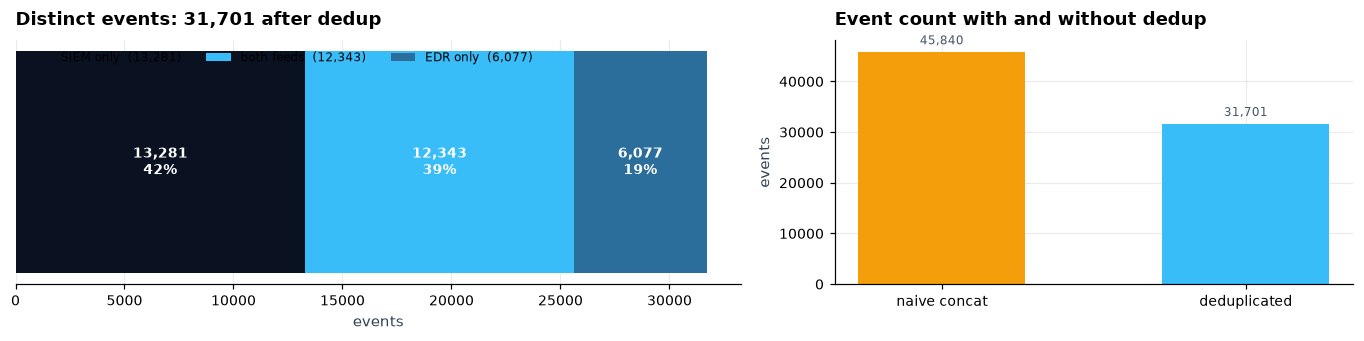

In [5]:
# The join key, expressed once in each feed's vocabulary.
siem_key = siem[["asset_id", "mitre_technique", "detected_at"]].rename(
    columns={"asset_id": "asset", "mitre_technique": "technique", "detected_at": "ts"})
edr_key = edr[["host", "ttp", "timestamp"]].rename(
    columns={"host": "asset", "ttp": "technique", "timestamp": "ts"})

# A row with a gap anywhere in the triple cannot be matched on it, in either
# direction. Those rows are excluded from the identity analysis and counted.
siem_complete = siem_key.notna().all(axis=1)
edr_complete = edr_key.notna().all(axis=1)
print(f"SIEM rows with a complete key: {siem_complete.sum():>7,} / {len(siem_key):,} "
      f"(excluded {(~siem_complete).sum()})")
print(f"EDR  rows with a complete key: {edr_complete.sum():>7,} / {len(edr_key):,} "
      f"(excluded {(~edr_complete).sum()})")

siem_keys = set(map(tuple, siem_key[siem_complete].to_numpy()))
edr_keys = set(map(tuple, edr_key[edr_complete].to_numpy()))

both, siem_only, edr_only = siem_keys & edr_keys, siem_keys - edr_keys, edr_keys - siem_keys
union = siem_keys | edr_keys

print()
print(f"SIEM distinct keys {len(siem_keys):>7,}   "
      f"(within-feed repeats: {siem_complete.sum() - len(siem_keys):,})")
print(f"EDR  distinct keys {len(edr_keys):>7,}   "
      f"(within-feed repeats: {edr_complete.sum() - len(edr_keys):,})")
print()
print(f"seen by BOTH feeds : {len(both):>7,}")
print(f"SIEM only          : {len(siem_only):>7,}")
print(f"EDR only           : {len(edr_only):>7,}")
print(f"distinct events    : {len(union):>7,}")
print()
print(f"naive concatenation: {len(siem) + len(edr):>7,} rows")
print(f"overcount          : {len(siem) + len(edr) - len(union):>7,} "
      f"(+{(len(siem) + len(edr)) / len(union) - 1:.1%} on every frequency)")
print(f"\nEDR events also in the SIEM : {len(both) / len(edr_keys):.1%}")
print(f"SIEM events also in the EDR : {len(both) / len(siem_keys):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.2), width_ratios=[1.4, 1])

left = 0
for value, label, colour in zip([len(siem_only), len(both), len(edr_only)],
                                ["SIEM only", "both feeds", "EDR only"],
                                [NAVY, ACCENT, "#2C6E9B"]):
    axes[0].barh(0, value, left=left, color=colour, height=0.5,
                 label=f"{label}  ({value:,})")
    axes[0].text(left + value / 2, 0, f"{value:,}\n{value / len(union):.0%}",
                 ha="center", va="center", color="white", fontsize=9, weight="bold")
    left += value
axes[0].set_title(f"Distinct events: {len(union):,} after dedup")
axes[0].set_yticks([])
axes[0].set_xlabel("events")
axes[0].legend(fontsize=8, ncols=3)
axes[0].spines["left"].set_visible(False)

axes[1].bar(["naive concat", "deduplicated"], [len(siem) + len(edr), len(union)],
            color=[WARN, ACCENT], width=0.55)
axes[1].set_title("Event count with and without dedup")
axes[1].set_ylabel("events")
bar_labels(axes[1])

plt.tight_layout()
plt.show()

**12,343 events carry an identical (asset, technique, timestamp) triple in both
feeds** — 67% of everything the EDR reports and 48% of what the SIEM reports. A
collision this exact is not coincidence: to the second, on the same asset, for the
same ATT&CK technique. The feeds are two partial observers of one event stream, not
two independent streams.

Concatenating them would report 45,840 rows where **31,701 distinct events**
occurred — a **+44.6% inflation applied to every annualized frequency**, and so to
the final loss.

Two smaller findings matter for implementation. Each feed also repeats keys
*internally* (761 in the SIEM, 543 in the EDR), so dedup must be a set operation over
the union rather than a pairwise join: an inner `merge` on these keys returns 13,055
rows, more than the 12,343 true matches, because duplicate keys multiply on both
sides. And 105 SIEM rows plus 387 EDR rows have a gap somewhere in the triple; they
cannot be matched in either direction, so they are kept as distinct events rather
than silently joined on a null.

**Decision:** the dedup key is the triple `(asset_id, mitre_technique, timestamp)`, applied to the *union* of both feeds. Duplicates collapse to one event carrying `sources=["siem","edr"]`; where the feeds disagree on severity the **maximum** is kept, on the principle that the worst observed signal is the one a defender must act on.

**Decision:** a row with an incomplete key is never dropped and never fuzzy-matched — it is carried as its own event and flagged `key_incomplete`, so it still counts toward frequency while being excluded from cross-feed reconciliation. The exclusion count is reported in the ingestion trace.

---

## 4 · Severity scales — translating EDR `risk` into SIEM classes

The SIEM grades severity in four text classes; the EDR emits a number. To combine
them the engine needs one scale. The events reported by both feeds are a free
labelled training set: each carries a SIEM class *and* an EDR score for the same
event.

SIEM severity classes:
  Low       12,843   48.5%
  Medium     6,167   23.3%
  High       5,394   20.4%
  Critical   1,769    6.7%
  (missing)    317    1.2%

EDR risk, as declared 0-999:
count    19350.00
mean        57.02
std         31.12
min          0.00
25%         35.00
50%         58.00
75%         78.00
max        999.00

values above 100 : 6 rows, distinct values [999]
maximum excluding those          : 100
99th percentile                  : 100
share of rows at exactly 100     : 5.45%


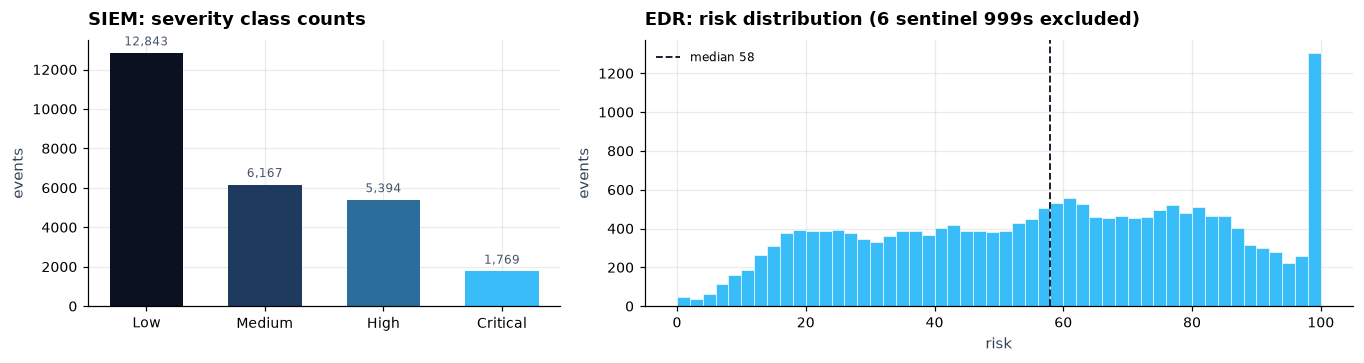

In [6]:
sev_counts = siem.severity.value_counts().reindex(SEV_ORDER)
print("SIEM severity classes:")
for cls, n in sev_counts.items():
    print(f"  {cls:9s} {n:>6,}  {n / len(siem):6.1%}")
print(f"  {'(missing)':9s} {siem.severity.isna().sum():>6,}  "
      f"{siem.severity.isna().mean():6.1%}")

print("\nEDR risk, as declared 0-999:")
print(edr.risk.describe().round(2).to_string())

above_100 = edr.risk[edr.risk > 100]
print(f"\nvalues above 100 : {len(above_100)} rows, distinct values {sorted(above_100.unique())}")
print(f"maximum excluding those          : {edr.risk[edr.risk <= 100].max()}")
print(f"99th percentile                  : {edr.risk.quantile(0.99):.0f}")
print(f"share of rows at exactly 100     : {edr.risk.eq(100).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4), width_ratios=[1, 1.5])
axes[0].bar(SEV_ORDER, sev_counts.to_numpy(), color=SEQ, width=0.62)
axes[0].set_title("SIEM: severity class counts")
axes[0].set_ylabel("events")
bar_labels(axes[0])

clean_risk = edr.risk[edr.risk <= 100]
axes[1].hist(clean_risk, bins=np.arange(0, 102, 2), color=ACCENT, edgecolor="white", lw=0.4)
axes[1].set_title("EDR: risk distribution (6 sentinel 999s excluded)")
axes[1].set_xlabel("risk")
axes[1].set_ylabel("events")
axes[1].axvline(clean_risk.median(), color=NAVY, ls="--", lw=1.2,
                label=f"median {clean_risk.median():.0f}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

The EDR field is documented as a 0–999 scale, but **the data does not use it that
way**: 19,344 of 19,350 rows fall in 0–100, the 99th percentile is 100, and exactly
six rows hold the value 999 — an out-of-band sentinel, not a score six times worse
than the worst real detection. Treating those six as genuine would put them above
every real event in any severity ranking and distort any threshold derived from the
range.

In [7]:
# The overlapping events: one event, two opinions on how bad it is.
# Usable as a label only when the EDR score is a real score and the SIEM graded it.
overlap = siem.merge(edr, left_on=["asset_id", "mitre_technique", "detected_at"],
                     right_on=["host", "ttp", "timestamp"], how="inner")
labelled = overlap[overlap.risk.le(100) & overlap.severity.notna()]
print(f"inner-merge rows            {len(overlap):>7,}")
print(f"  after dropping risk == 999 {int(overlap.risk.le(100).sum()):>7,}")
print(f"  after dropping unlabelled  {len(labelled):>7,}  <- training set for the cut points")

print("\nSIEM class x EDR risk quartile - the two scales are strongly monotone:")
display(pd.crosstab(labelled.severity,
                    pd.qcut(labelled.risk, 4, labels=["Q1", "Q2", "Q3", "Q4"]),
                    ).reindex(SEV_ORDER))

display(labelled.groupby("severity").risk.agg(
    n="count", p05=lambda s: s.quantile(0.05), median="median",
    p95=lambda s: s.quantile(0.95)).reindex(SEV_ORDER).round(1))

inner-merge rows             13,055
  after dropping risk == 999  13,051
  after dropping unlabelled   12,887  <- training set for the cut points

SIEM class x EDR risk quartile - the two scales are strongly monotone:


risk,Q1,Q2,Q3,Q4
severity,,,,
Low,3293,2383,61,0
Medium,1,896,2100,51
High,0,3,1087,1845
Critical,0,0,2,1165


,n,p05,median,p95
severity,,,,
Low,5737,9.0,28.0,49.2
Medium,3048,46.0,60.0,73.0
High,2935,66.0,80.0,93.0
Critical,1167,86.0,99.0,100.0


In [8]:
"""Derive cut points by maximizing agreement with the SIEM label.

Grid search over every (c1, c2, c3) with 0 < c1 < c2 < c3 <= 100. Scoring is O(1)
per candidate: pre-bin the labelled overlap into a 101 x 4 count matrix and take the
cumulative sum per class, so an otherwise 160k-candidate search is instantaneous.
"""

# Ordered categorical rather than a dict lookup: codes are guaranteed 0..3 in
# SEV_ORDER, and anything outside the four classes would surface as -1 rather than
# silently becoming a NaN that later arithmetic ignores.
severity_codes = pd.Categorical(labelled.severity, categories=SEV_ORDER, ordered=True).codes
assert (severity_codes >= 0).all(), "unexpected severity label in the labelled overlap"
y = severity_codes.astype(np.int64)
r = labelled.risk.to_numpy().astype(int)

counts = np.zeros((101, 4), dtype=np.int64)
np.add.at(counts, (r, y), 1)
# cum[k, c] = number of events with risk < k in class c
cum = np.vstack([np.zeros((1, 4), dtype=np.int64), counts.cumsum(axis=0)])


def agreement(c1, c2, c3):
    """Events the cut points assign to the same class the SIEM did."""
    return int(cum[c1, 0]
               + (cum[c2, 1] - cum[c1, 1])
               + (cum[c3, 2] - cum[c2, 2])
               + (cum[101, 3] - cum[c3, 3]))


best_score, best_cuts = -1, None
for c1 in range(1, 99):
    for c2 in range(c1 + 1, 100):
        for c3 in range(c2 + 1, 101):
            score = agreement(c1, c2, c3)
            if score > best_score:
                best_score, best_cuts = score, (c1, c2, c3)

predicted = np.digitize(r, list(best_cuts))

print(f"CHOSEN CUT POINTS          : {best_cuts}")
print(f"exact agreement            : {best_score / len(labelled):.2%} of {len(labelled):,} labelled events")
print(f"within one class           : {(np.abs(predicted - y) <= 1).mean():.2%}")
print("\nmapping applied to EDR risk:")
for cls, lo, hi in zip(SEV_ORDER, [0, *best_cuts], [*best_cuts, 101]):
    print(f"  risk in [{lo:>3}, {hi - 1:>3}]  ->  {cls}")

print("\nsensitivity to rounder thresholds:")
for cuts in [best_cuts, (50, 70, 90), (45, 70, 90), (50, 75, 90), (58, 76, 98)]:
    print(f"  {str(cuts):16s} agreement {agreement(*cuts) / len(labelled):.2%}")

confusion = pd.crosstab(
    pd.Series(y).map(dict(enumerate(SEV_ORDER))).rename("SIEM label"),
    pd.Series(predicted).map(dict(enumerate(SEV_ORDER))).rename("mapped from EDR risk"),
).reindex(index=SEV_ORDER, columns=SEV_ORDER).fillna(0).astype(int)
display(confusion)

CHOSEN CUT POINTS          : (50, 70, 94)
exact agreement            : 87.14% of 12,887 labelled events


within one class           : 100.00%

mapping applied to EDR risk:
  risk in [  0,  49]  ->  Low
  risk in [ 50,  69]  ->  Medium
  risk in [ 70,  93]  ->  High
  risk in [ 94, 100]  ->  Critical

sensitivity to rounder thresholds:
  (50, 70, 94)     agreement 87.14%
  (50, 70, 90)     agreement 86.73%
  (45, 70, 90)     agreement 85.26%
  (50, 75, 90)     agreement 84.86%
  (58, 76, 98)     agreement 78.80%


mapped from EDR risk,Low,Medium,High,Critical
SIEM label,,,,
Low,5450,287,0,0
Medium,333,2385,330,0
High,0,331,2486,118
Critical,0,0,258,909


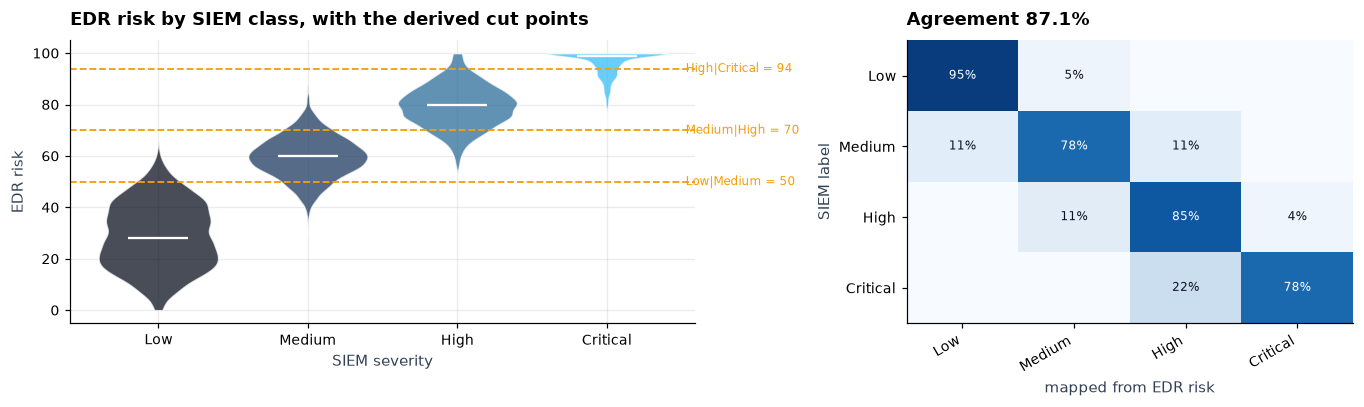

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), width_ratios=[1.4, 1])

data = [labelled.loc[labelled.severity == cls, "risk"].to_numpy() for cls in SEV_ORDER]
parts = axes[0].violinplot(data, positions=range(4), widths=0.8, showmedians=True,
                           showextrema=False)
for body, colour in zip(parts["bodies"], SEQ):
    body.set_facecolor(colour)
    body.set_alpha(0.75)
    body.set_edgecolor("white")
parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(1.5)
for cut, label in zip(best_cuts, ["Low|Medium", "Medium|High", "High|Critical"]):
    axes[0].axhline(cut, color=WARN, ls="--", lw=1.2)
    axes[0].text(3.5, cut, f" {label} = {cut}", fontsize=8, color=WARN, va="center")
axes[0].set_xticks(range(4), SEV_ORDER)
axes[0].set_title("EDR risk by SIEM class, with the derived cut points")
axes[0].set_ylabel("EDR risk")
axes[0].set_xlabel("SIEM severity")

norm = confusion.div(confusion.sum(axis=1), axis=0).to_numpy()
axes[1].imshow(norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(4), SEV_ORDER, rotation=30, ha="right")
axes[1].set_yticks(range(4), SEV_ORDER)
axes[1].set_xlabel("mapped from EDR risk")
axes[1].set_ylabel("SIEM label")
axes[1].set_title(f"Agreement {best_score / len(labelled):.1%}")
axes[1].grid(False)
for i in range(4):
    for j in range(4):
        if norm[i, j] > 0.005:
            axes[1].text(j, i, f"{norm[i, j]:.0%}", ha="center", va="center", fontsize=8,
                         color="white" if norm[i, j] > 0.5 else NAVY)

plt.tight_layout()
plt.show()

The two scales are strongly monotone: 98.9% of SIEM `Low` events sit in the bottom
two EDR quartiles, and 99.8% of `Critical` events sit in the top one. Cut points at
**50 / 70 / 94** reproduce the SIEM label for **87.1%** of the 12,887 labelled events
and land within one class for **100.0%** of them — there is not a single event the
two tools disagree about by more than one grade. The residual disagreement is
entirely on borderline events, and no threshold can remove it.

The choice is not delicate: rounding to 50/70/90 costs 0.4 points of agreement. An
alternative derivation — cut points that reproduce the SIEM's *marginal* class shares
— yields 58/76/98 but only 78.8% agreement, because it optimizes the wrong thing.
Classifying each event correctly matters more than matching totals.

**Decision:** EDR `risk` maps to SIEM classes at **50 / 70 / 94** (`<50` Low, `50–69` Medium, `70–93` High, `≥94` Critical), then onto the shared 0.25 / 0.5 / 0.75 / 1.0 numeric scale. These become named constants in `risk_engine.ingestion` with a comment pointing back to this section.

**Decision:** `risk == 999` is an out-of-band sentinel, not a score. The six affected rows are treated as *severity unknown*: where such an event also appears in the SIEM the SIEM class is used, and otherwise it is excluded from severity-thresholded counts rather than ranked above every real detection.

**Decision:** the same rule covers the 317 SIEM rows with no `severity` — unknown severity is propagated as unknown, never defaulted to `Low`. Where the other feed graded the same event the cross-feed maximum resolves it; otherwise the event counts toward volume but not toward the attack-grade threshold, and the count of such events is reported so a reader can see how much of the estate is ungraded.

---

## 5 · Event mix — what kind of activity is on the estate

Frequency is modelled per attack type, so the shape of the technique mix — and
whether it varies by asset — decides how far the telemetry can be segmented before
the counts get too thin.

distinct MITRE techniques: SIEM 21, EDR 21
top 3 account for 33% of SIEM volume
rows usable here: 26,069 of 26,490 (dropped 421 with no asset or no severity)


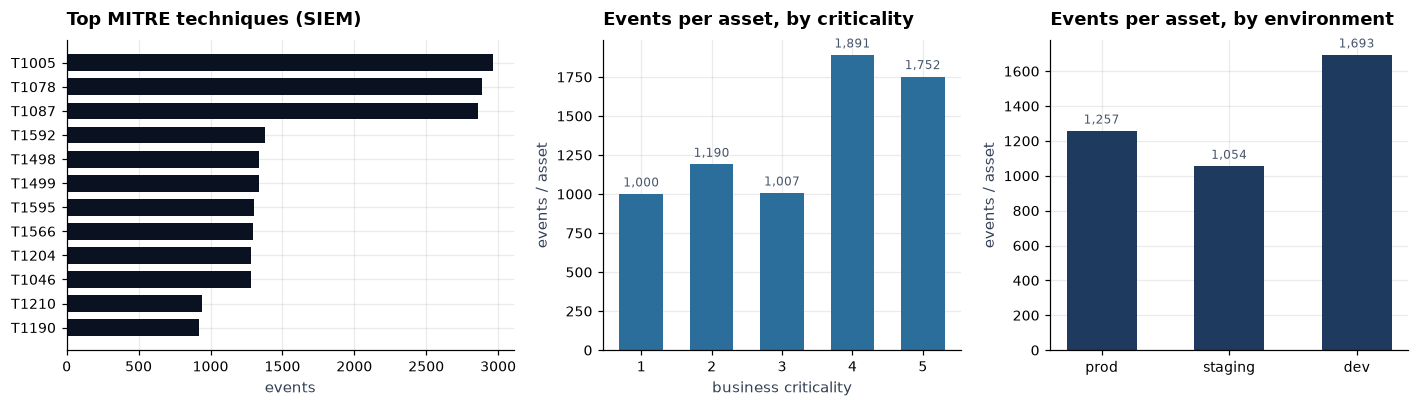


attack-grade (High+Critical) share, by criticality:
business_criticality
1    0.2649
2    0.2718
3    0.2766
4    0.2751
5    0.2733

by environment:
environment
dev        0.2726
prod       0.2758
staging    0.2681


In [10]:
print(f"distinct MITRE techniques: SIEM {siem.mitre_technique.nunique()}, "
      f"EDR {edr.ttp.nunique()}")

top = siem.mitre_technique.value_counts().head(12)
print(f"top 3 account for {top.head(3).sum() / len(siem):.0%} of SIEM volume")

# Graded events on a known asset: the rows that can speak to both questions below.
enriched = (siem.dropna(subset=["asset_id", "severity"])
            .merge(assets, on="asset_id", validate="many_to_one"))
print(f"rows usable here: {len(enriched):,} of {len(siem):,} "
      f"(dropped {len(siem) - len(enriched):,} with no asset or no severity)")
per_crit = (enriched.groupby("business_criticality").size()
            / assets.business_criticality.value_counts().sort_index())
per_env = enriched.groupby("environment").size() / assets.environment.value_counts()
enriched["attack_grade"] = enriched.severity.isin(["High", "Critical"])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), width_ratios=[1.25, 1, 1])
axes[0].barh(top.index[::-1], top.to_numpy()[::-1], color=NAVY, height=0.7)
axes[0].set_title("Top MITRE techniques (SIEM)")
axes[0].set_xlabel("events")

axes[1].bar(per_crit.index, per_crit.to_numpy(), color=SEQ[2], width=0.62)
axes[1].set_title("Events per asset, by criticality")
axes[1].set_xlabel("business criticality")
axes[1].set_ylabel("events / asset")
axes[1].set_xticks([1, 2, 3, 4, 5])
bar_labels(axes[1])

order_env = ["prod", "staging", "dev"]
axes[2].bar(order_env, per_env.reindex(order_env).to_numpy(), color=SEQ[1], width=0.55)
axes[2].set_title("Events per asset, by environment")
axes[2].set_ylabel("events / asset")
bar_labels(axes[2])

plt.tight_layout()
plt.show()

print("\nattack-grade (High+Critical) share, by criticality:")
print(enriched.groupby("business_criticality").attack_grade.mean().round(4).to_string())
print("\nby environment:")
print(enriched.groupby("environment").attack_grade.mean().round(4).to_string())

Twenty-one techniques, spread thinly: the top three (T1005 data collection, T1078
valid accounts, T1087 account discovery) account for 33% of SIEM volume and the
remaining eighteen share the rest. Volume varies about two-fold per asset across
criticality levels, with the criticality-4 assets noisiest.

The important result here is a negative one. The attack-grade share sits in a
**26.5–27.7% band across every criticality level and every environment** — a spread
of barely one point where criticality spans 1 to 5. Severity is effectively
independent of business context: the feeds grade the *technical* signal and know
nothing about what an asset is worth. Any business-impact weighting must therefore
come from the asset reference; it cannot be recovered from the telemetry.

**Decision:** frequency is modelled per attack type, mapped from MITRE technique, not per technique — 21 techniques over a 212-day window leaves too few episodes per cell to estimate a rate. Severity thresholds are applied uniformly across assets, and business criticality enters later through exposure, never by reweighting event severity.

---

## 6 · Incident base quality — encoding damage and missing-value sentinels

The external base of 1,600 incidents is what calibrates severity in euros. Two
defects have to be repaired before any of it is trustworthy, and both fail silently.

In [11]:
print(f"{len(incidents):,} incidents, {incidents.company_id.nunique():,} distinct organisations, "
      f"{incidents.date.min():%Y-%m-%d} to {incidents.date.max():%Y-%m-%d}")

print(f"\nraw `sector` labels: {incidents.sector.nunique()}")
for label, n in incidents.sector.value_counts().items():
    flag = "   <-- double-encoded" if any(ch in label for ch in "\u00c3\u00c2") else ""
    print(f"  {n:>5,}  {label!r}{flag}")

1,600 incidents, 1,310 distinct organisations, 2022-01-01 to 2025-12-29

raw `sector` labels: 9
    319  'Retail'
    283  'Finance'
    238  'Tech/SaaS'
    236  'Santé'
    219  'Industrie'
    163  'Énergie'
    129  'Public'
      8  'Ã‰nergie'   <-- double-encoded
      5  'SantÃ©'   <-- double-encoded


In [12]:
"""Repair double-encoded text rather than hardcoding the two labels we happen to see.

The damage is UTF-8 bytes decoded as cp1252 and re-encoded as UTF-8: 'Energie'
becomes 'A~E0/00nergie'. Reversing it is exact - encode back to cp1252, decode as
UTF-8 - and it fails loudly on text that was never damaged, which is how clean and
damaged labels are told apart. A lookup table would silently miss any label not in it.
"""

def repair_mojibake(text):
    """Undo one round of cp1252/UTF-8 double encoding; return input unchanged if clean."""
    try:
        return text.encode("cp1252").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


incidents["sector_clean"] = incidents.sector.map(repair_mojibake)

print("repairs applied:")
display(incidents.loc[incidents.sector != incidents.sector_clean, ["sector", "sector_clean"]]
        .value_counts().rename("rows").reset_index())
print(f"sector labels: {incidents.sector.nunique()} raw -> {incidents.sector_clean.nunique()} clean")
print("\nfinal sector distribution:")
print(incidents.sector_clean.value_counts().to_string())

repairs applied:


,sector,sector_clean,rows
0,Ã‰nergie,Énergie,8
1,SantÃ©,Santé,5


sector labels: 9 raw -> 7 clean

final sector distribution:
sector_clean
Retail       319
Finance      283
Santé        241
Tech/SaaS    238
Industrie    219
Énergie      171
Public       129


financial_loss_eur == -1 : 2 rows (0.12%)
financial_loss_eur == 0  : 0 rows
other negatives          : 0 rows

if the sentinel were read as EUR 0, the mean loss would move from 609,836 to 609,074 EUR

other missing values: records_exposed 48, downtime_hours 80


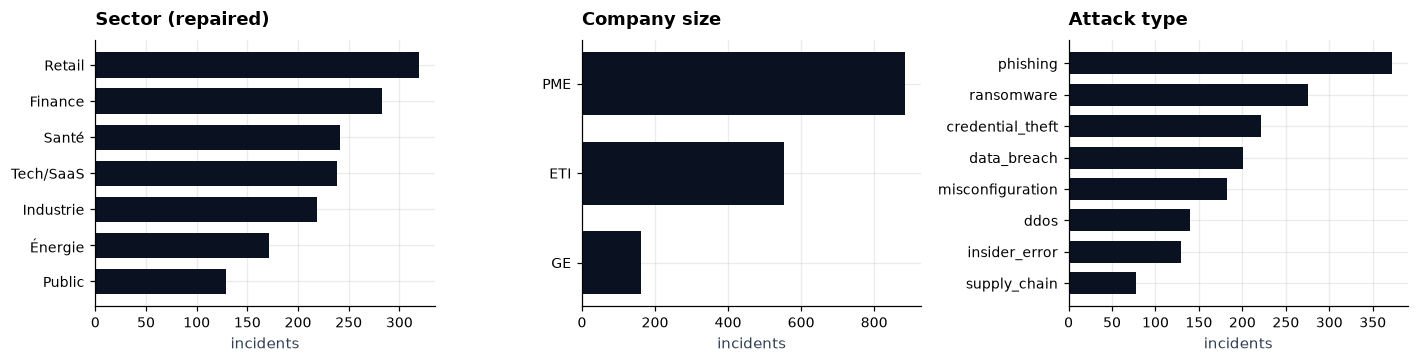

In [13]:
sentinels = incidents.financial_loss_eur.eq(-1)
print(f"financial_loss_eur == -1 : {sentinels.sum()} rows ({sentinels.mean():.2%})")
print(f"financial_loss_eur == 0  : {incidents.financial_loss_eur.eq(0).sum()} rows")
print(f"other negatives          : {incidents.financial_loss_eur.lt(-1).sum()} rows")
print(f"\nif the sentinel were read as EUR 0, the mean loss would move from "
      f"{incidents.loc[~sentinels, 'financial_loss_eur'].mean():,.0f} to "
      f"{incidents.financial_loss_eur.clip(lower=0).mean():,.0f} EUR")

# The sentinel means "not reported", so it becomes NaN and is excluded from fits.
incidents["loss_eur"] = incidents.financial_loss_eur.where(~sentinels)
print(f"\nother missing values: records_exposed {incidents.records_exposed.isna().sum()}, "
      f"downtime_hours {incidents.downtime_hours.isna().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, title in [(axes[0], "sector_clean", "Sector (repaired)"),
                       (axes[1], "company_size", "Company size"),
                       (axes[2], "attack_type", "Attack type")]:
    counts = incidents[col].value_counts()
    ax.barh(counts.index[::-1], counts.to_numpy()[::-1], color=NAVY, height=0.7)
    ax.set_title(title)
    ax.set_xlabel("incidents")
plt.tight_layout()
plt.show()

**Encoding.** Nine distinct sector labels exist where there are seven sectors: 13
rows carry a double-encoded spelling (`Ã‰nergie` ×8, `SantÃ©` ×5) of labels that are
correctly encoded everywhere else. Left alone they split `Énergie` into two sectors
and `Santé` into two, quietly shrinking both peer pools. The repair is reversible and
self-validating rather than a lookup table, so a label damaged some other way is
still caught.

**Sentinels.** `financial_loss_eur == -1` appears on **2 rows**. Small, but the
failure mode is not: `-1` reads as a valid float, so a mean over the raw column
silently mixes a sentinel into the arithmetic — and clipping it to zero would be
worse, because it asserts an incident cost nothing. `records_exposed` (48 rows) and
`downtime_hours` (80) are properly `NaN` already.

The base is otherwise well populated: 1,600 incidents over four years across 7
sectors, 3 size bands and 8 attack types, skewed toward PME (55%) and phishing (23%).

**Decision:** ingestion repairs mojibake by round-tripping through cp1252/UTF-8 rather than by lookup table, and maps `financial_loss_eur == -1` to `NaN` before any statistic is computed. Rows with unknown loss are dropped from severity fitting and reported as an exclusion count, never imputed as €0.

---

## 7 · Loss distribution — how heavy is the tail?

The severity model is a distribution over euros per incident. Choosing its family is
the most consequential modeling decision in the engine, because it is the tail that
drives VaR and TVaR.

In [14]:
loss = incidents.loss_eur.dropna()
log_loss = np.log(loss)

print(pd.Series({
    "n": len(loss), "min": loss.min(), "p25": loss.quantile(0.25),
    "median": loss.median(), "mean": loss.mean(), "p75": loss.quantile(0.75),
    "p95": loss.quantile(0.95), "p99": loss.quantile(0.99), "max": loss.max(),
}).map(lambda v: f"{v:,.0f}").to_string())

print(f"\nmean / median ratio  : {loss.mean() / loss.median():.1f}x")
print(f"skewness (raw)       : {stats.skew(loss):.2f}   kurtosis {stats.kurtosis(loss):,.0f}")
print(f"skewness (log)       : {stats.skew(log_loss):.2f}   kurtosis {stats.kurtosis(log_loss):.2f}")
print(f"top  1% of incidents : {loss.nlargest(len(loss) // 100).sum() / loss.sum():.1%} of all losses")
print(f"top 10% of incidents : {loss.nlargest(len(loss) // 10).sum() / loss.sum():.1%} of all losses")

mu, sigma = log_loss.mean(), log_loss.std(ddof=0)
ks = stats.kstest(log_loss, "norm", args=(mu, sigma))
print(f"\npooled lognormal fit : mu={mu:.4f} sigma={sigma:.4f} -> median {np.exp(mu):,.0f} EUR")
print(f"KS test on the logs  : D={ks.statistic:.4f}  p={ks.pvalue:.2e}  "
      f"-> {'REJECTED' if ks.pvalue < 0.05 else 'not rejected'} at 5%")

n              1,598
min            1,000
p25           15,241
median        39,066
mean         609,836
p75          170,046
p95        3,442,276
p99        8,662,758
max       31,606,679

mean / median ratio  : 15.6x
skewness (raw)       : 7.39   kurtosis 78
skewness (log)       : 0.80   kurtosis -0.04
top  1% of incidents : 24.4% of all losses
top 10% of incidents : 79.9% of all losses

pooled lognormal fit : mu=11.0626 sigma=1.9670 -> median 63,739 EUR
KS test on the logs  : D=0.1072  p=1.87e-16  -> REJECTED at 5%


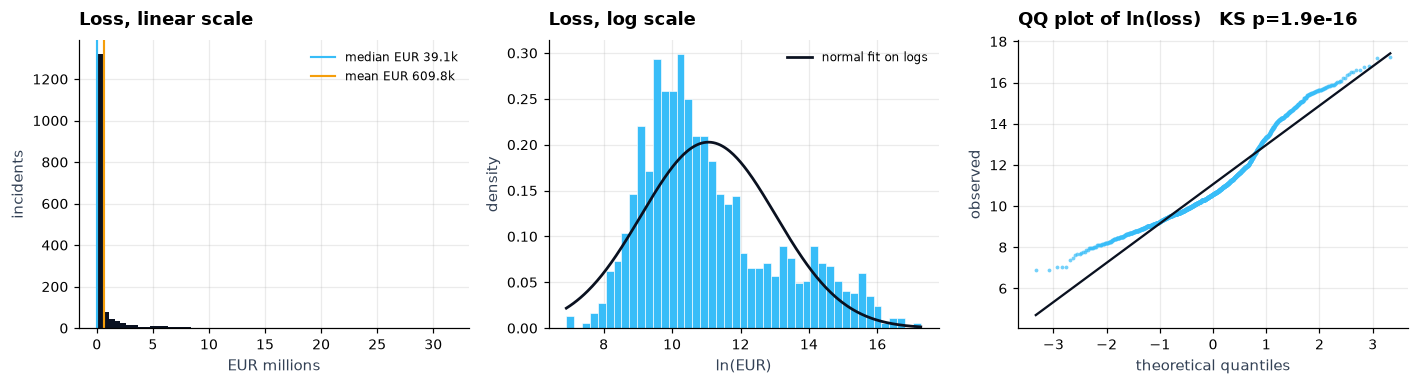

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].hist(loss / 1e6, bins=60, color=NAVY)
axes[0].set_title("Loss, linear scale")
axes[0].set_xlabel("EUR millions")
axes[0].set_ylabel("incidents")
axes[0].axvline(loss.median() / 1e6, color=ACCENT, lw=1.4, label=f"median {eur(loss.median())}")
axes[0].axvline(loss.mean() / 1e6, color=WARN, lw=1.4, label=f"mean {eur(loss.mean())}")
axes[0].legend(fontsize=8)

axes[1].hist(log_loss, bins=45, color=ACCENT, edgecolor="white", lw=0.4, density=True)
grid = np.linspace(log_loss.min(), log_loss.max(), 300)
axes[1].plot(grid, stats.norm.pdf(grid, mu, sigma), color=NAVY, lw=1.8, label="normal fit on logs")
axes[1].set_title("Loss, log scale")
axes[1].set_xlabel("ln(EUR)")
axes[1].set_ylabel("density")
axes[1].legend(fontsize=8)

stats.probplot(log_loss, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set(marker="o", markersize=2.5, markerfacecolor=ACCENT,
                           markeredgecolor="none", alpha=0.7)
axes[2].get_lines()[1].set(color=NAVY, lw=1.5)
axes[2].set_title(f"QQ plot of ln(loss)   KS p={ks.pvalue:.1e}")
axes[2].set_xlabel("theoretical quantiles")
axes[2].set_ylabel("observed")

plt.tight_layout()
plt.show()

,n,mu,sigma,median,KS,p,lognormal
segment,,,,,,,
pooled,1598,11.063,1.967,"63,739",0.1072,0.000,rejected
severity = catastrophic,89,15.620,0.507,"6,079,301",0.1122,0.197,holds
severity = major,130,13.193,0.321,"536,660",0.0804,0.351,holds
severity = minor,886,9.653,0.745,"15,572",0.0594,0.004,rejected
severity = moderate,375,11.539,0.485,"102,623",0.0873,0.006,rejected
severity = severe,118,14.346,0.295,"1,699,431",0.0658,0.661,holds


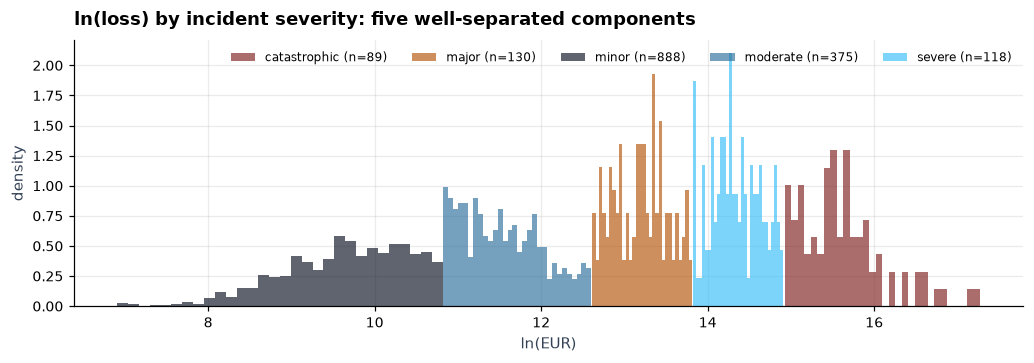

In [16]:
"""Why the pooled fit is rejected: the pool is a mixture of severity strata."""

rows = []
for label, subset in [("pooled", loss)] + [
        (f"severity = {s}", g.loss_eur.dropna()) for s, g in incidents.groupby("severity")]:
    ln = np.log(subset)
    m, sd = ln.mean(), ln.std(ddof=0)
    test = stats.kstest(ln, "norm", args=(m, sd))
    rows.append({"n": len(subset), "mu": round(m, 3), "sigma": round(sd, 3),
                 "median": f"{np.exp(m):,.0f}", "KS": round(test.statistic, 4),
                 "p": f"{test.pvalue:.3f}",
                 "lognormal": "rejected" if test.pvalue < 0.05 else "holds",
                 "segment": label})
display(pd.DataFrame(rows).set_index("segment"))

fig, ax = plt.subplots(figsize=(9.5, 3.4))
for (label, group), colour in zip(incidents.groupby("severity"),
                                  ["#7F1D1D", "#B45309", "#0A1120", "#2C6E9B", "#38BDF8"]):
    ax.hist(np.log(group.loss_eur.dropna()), bins=30, alpha=0.65, density=True,
            color=colour, label=f"{label} (n={len(group)})")
ax.set_title("ln(loss) by incident severity: five well-separated components")
ax.set_xlabel("ln(EUR)")
ax.set_ylabel("density")
ax.legend(fontsize=8, ncols=5)
plt.tight_layout()
plt.show()

The tail is unambiguous. The mean loss (€609,836) is **15.6× the median** (€39,066),
raw skewness is 7.4, and the worst 1% of incidents carry 24% of all euros while the
worst 10% carry 80%. A model built on averages would be wrong in the direction that
matters most.

Taking logs removes almost all of it: skewness falls from 7.4 to 0.80 and excess
kurtosis to ≈0. The histogram of `ln(loss)` is close to bell-shaped and the QQ plot
is straight through the body of the distribution.

But it is **not** straight at the ends, and the KS test on the pooled logs rejects
normality decisively (D=0.107, p≈2×10⁻¹⁶). The reason is visible once the pool is
split: the base is a **mixture** of five severity strata whose log-losses are each
well separated and individually far closer to normal — `severe` (p=0.66), `major`
(p=0.35) and `catastrophic` (p=0.20) are not rejected at all. Pooling five narrow
lognormals with medians from €15.6k to €6.1M produces something visibly lumpy that
no single lognormal can match.

This is exactly the check the brief asks for, and it comes out as a qualified yes:
the log scale is right, one global lognormal is not.

**Decision:** severity is fitted as a **lognormal on the log scale**, with parameters estimated **per segment** (attack type, under peer weighting) rather than once over the pool — the pooled KS rejection is a mixture artefact, and fitting a mixture as though it were one component would understate the spread. The KS statistic and effective sample size are reported next to every fitted component so a reviewer can see which fits are trustworthy.

**Decision:** the gap between mean and median is surfaced explicitly in the API output. AAL is driven by the mean, but a decision-maker reading a single number needs to know the typical incident costs a fifteenth of it.

---

## 8 · Peer group — the sample size versus relevance trade-off

The target company is an **ETI in Retail/e-commerce, 1,200 employees, security
maturity 55/100**. Severity should be calibrated on comparable organisations. The
question is how comparable we can afford to be.

In [17]:
usable = incidents.dropna(subset=["loss_eur"])
MIN_PER_CELL = 30  # below this an attack-type-specific fit is not credible
n_types = usable.attack_type.nunique()

peer_groups = {
    "ETI + Retail (exact match)": usable.company_size.eq("ETI") & usable.sector_clean.eq("Retail"),
    "+ maturity 45-65": (usable.company_size.eq("ETI") & usable.sector_clean.eq("Retail")
                         & usable.security_maturity_score.between(45, 65)),
    "Retail, all sizes": usable.sector_clean.eq("Retail"),
    "ETI, all sectors": usable.company_size.eq("ETI"),
    "All incidents": pd.Series(True, index=usable.index),
}

rows = []
for name, mask in peer_groups.items():
    subset = usable[mask]
    per_type = subset.attack_type.value_counts().reindex(usable.attack_type.unique()).fillna(0)
    rows.append({
        "peer group": name,
        "n": len(subset),
        "median loss": f"{subset.loss_eur.median():,.0f}",
        "sigma(log)": round(float(np.log(subset.loss_eur).std(ddof=0)), 3),
        "smallest attack cell": int(per_type.min()),
        f"cells n>={MIN_PER_CELL}": f"{int((per_type >= MIN_PER_CELL).sum())} / {n_types}",
    })
display(pd.DataFrame(rows).set_index("peer group"))

exact = usable[peer_groups["ETI + Retail (exact match)"]]
print("attack-type counts inside the exact-match peer group:")
print(exact.attack_type.value_counts().to_string())
print(f"\nNot one of the {n_types} attack types reaches n>={MIN_PER_CELL}. "
      f"Largest cell: {exact.attack_type.value_counts().max()}.")
print(f"\nexact-match profile: employees median {exact.employees.median():,.0f} (target 1,200), "
      f"maturity median {exact.security_maturity_score.median():.0f} (target 55)")

,n,median loss,sigma(log),smallest attack cell,cells n>=30
peer group,,,,,
ETI + Retail (exact match),112,"69,865",1.866,4,0 / 8
+ maturity 45-65,64,"85,416",1.944,2,0 / 8
"Retail, all sizes",319,"42,345",1.997,19,6 / 8
"ETI, all sectors",554,"75,184",1.912,24,7 / 8
All incidents,1598,"39,066",1.967,78,8 / 8


attack-type counts inside the exact-match peer group:
attack_type
phishing            26
credential_theft    20
ransomware          16
data_breach         15
ddos                11
misconfiguration    11
insider_error        9
supply_chain         4

Not one of the 8 attack types reaches n>=30. Largest cell: 26.

exact-match profile: employees median 852 (target 1,200), maturity median 48 (target 55)


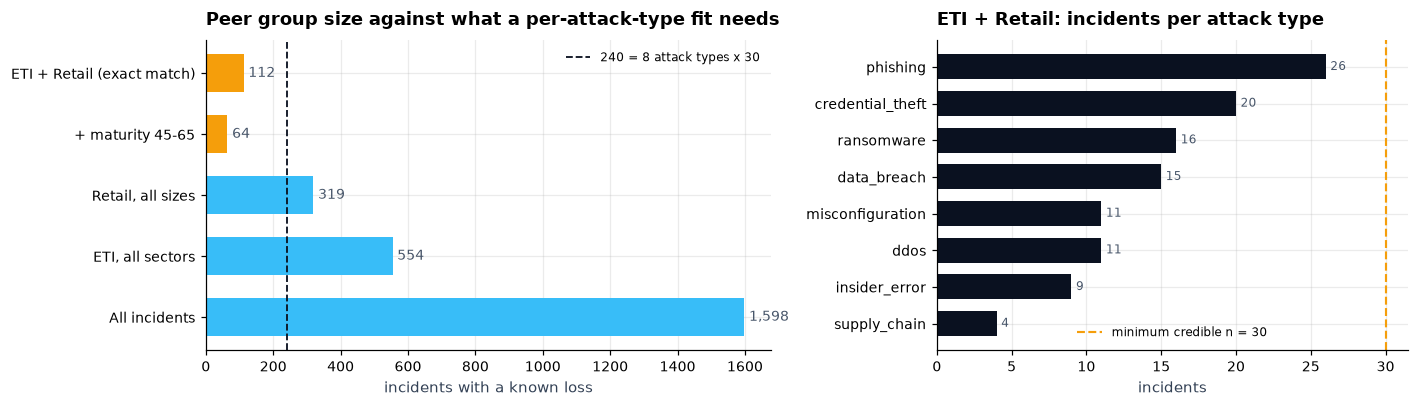

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[1.2, 1])

names = list(peer_groups)
sizes = [int(peer_groups[n].sum()) for n in names]
needed = n_types * MIN_PER_CELL
axes[0].barh(names[::-1], sizes[::-1], height=0.62,
             color=[(WARN if s < needed else ACCENT) for s in sizes][::-1])
axes[0].axvline(needed, color=NAVY, ls="--", lw=1.2,
                label=f"{needed} = {n_types} attack types x {MIN_PER_CELL}")
axes[0].set_title("Peer group size against what a per-attack-type fit needs")
axes[0].set_xlabel("incidents with a known loss")
axes[0].legend(fontsize=8)
for i, s in enumerate(sizes[::-1]):
    axes[0].text(s + 14, i, f"{s:,}", va="center", fontsize=9, color="#475569")

cells = exact.attack_type.value_counts().sort_values()
axes[1].barh(cells.index, cells.to_numpy(), color=NAVY, height=0.68)
axes[1].axvline(MIN_PER_CELL, color=WARN, ls="--", lw=1.4,
                label=f"minimum credible n = {MIN_PER_CELL}")
axes[1].set_title("ETI + Retail: incidents per attack type")
axes[1].set_xlabel("incidents")
axes[1].legend(fontsize=8)
bar_labels(axes[1])

plt.tight_layout()
plt.show()

Hard filtering collapses immediately. The exact ETI + Retail match keeps **112 of
1,598 incidents** — 7% of the base — and once split across eight attack types **not a
single cell reaches 30 observations**; the largest, phishing, has 26, and supply chain
has 4. Adding the maturity band the target actually sits in cuts it to 64. There is no
per-attack-type severity model to be had from a hard-filtered peer group.

Widening one dimension at a time recovers sample but discards relevance: `Retail, all
sizes` (n=319) mixes in PME with a median loss of €42k, and `ETI, all sectors` (n=554)
reaches a median of €75k but imports Finance and Énergie loss profiles. Neither is the
target. The exact-match group is itself a compromise: its median company has 852
employees against the target's 1,200, and median maturity 48 against 55 — even "exact"
matching leaves real distance on the continuous attributes.

The trade-off has no good discrete answer, which is the argument for not making it
discrete. Every incident carries a *degree* of similarity to the target; a hard filter
throws that away by rounding it to 0 or 1.

**Decision:** the peer group is built by **soft weighting, not filtering**. Each incident receives a weight from a sector-match term and Gaussian kernels on log-employees and maturity distance; all 1,598 incidents contribute, with the closest dominating. Every fit reports its **effective sample size** (Kish, `(Σw)² / Σw²`) rather than a raw row count, so a reader can see how much real information stands behind each parameter.

**Decision:** an attack-type-specific fit is used only where the effective sample size reaches 30; below that the engine falls back to the pooled weighted fit and records the fallback in the explanation trace. On this data that threshold is binding — which is precisely why it must be explicit rather than discovered later.

---

## Decisions carried into `risk_engine`

| § | Decision | Lands in |
|---|---|---|
| 1 | Business context comes only from `asset_reference`, joined on `asset_id` | `ingestion` |
| 2 | `observed_days` = distinct calendar days in the union of feeds; annualization `365 / observed_days` ≈ 1.7217, always recomputed | `frequency` |
| 3 | Dedup on `(asset_id, mitre_technique, timestamp)` over the union; keep max severity, `sources=["siem","edr"]` | `ingestion` |
| 3 | Incomplete keys are carried as distinct events and flagged, never fuzzy-matched or dropped | `ingestion` |
| 4 | EDR `risk` → classes at **50 / 70 / 94**; `risk == 999` is a sentinel, not a score | `ingestion` |
| 4 | Unknown severity propagates as unknown; never defaulted to `Low` | `ingestion` |
| 5 | Model frequency per attack type, not per technique; severity thresholds uniform across assets | `frequency` |
| 6 | Repair mojibake by cp1252/UTF-8 round-trip; `financial_loss_eur == -1` → `NaN`, never €0 | `ingestion` |
| 7 | Lognormal on the log scale, fitted **per segment**; pooled KS rejection is a mixture artefact; report the mean-vs-median gap | `severity` |
| 8 | Soft peer weighting over all 1,598 incidents; report Kish effective sample size; pooled fallback below n_eff = 30 | `severity` |

Three findings contradict assumptions worth re-checking before anything else relies
on them:

1. The EDR scale is **0–100 with six 999 sentinels**, not a genuine 0–999 range.
2. A single pooled lognormal is **rejected** by KS (p≈2×10⁻¹⁶) even though the log
   scale is clearly right — the pool is a mixture of five severity strata.
3. The telemetry has **real gaps and exact duplicate rows** in both feeds. Every
   count in this notebook states which rows it excluded and why; the engine does the
   same in its explanation trace.